### Importing Dependencies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

#### Load Data

In [2]:
#loading the data
df = pd.read_csv('../data/sudan.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


#### Data Parsing

In [3]:
#Add a country column with the country name
df['country'] = 'Sudan'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [4]:
#Convert the YEAR and DOY columns to a proper datetime format
df['date'] = pd.to_datetime(df['YEAR']*1000 + df['DOY'], format="%Y%j")
df['month'] = df['date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


### Summary Statistics & Missing-Value Report

In [5]:
#Replace the -999 values with NaN
df.replace(-999, np.nan)
df.describe()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,country,date,month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [6]:
# Check for duplicates
df.duplicated().sum()

0

In [7]:
#Numeric columns describe
df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].describe()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,28.759007,36.773914,21.508510,0.643875,31.359192,3.484253,5.157378
std,4.681305,4.400065,5.091142,3.057672,17.851849,1.040667,1.280238
min,13.180000,21.040000,5.930000,0.000000,4.690000,0.610000,1.030000
25%,25.560000,33.730000,17.497500,0.000000,17.407500,2.730000,4.267500
50%,29.160000,37.020000,22.890000,0.000000,26.630000,3.490000,5.120000
75%,32.510000,40.330000,25.430000,0.010000,40.535000,4.220000,6.020000
max,37.990000,45.960000,32.170000,66.490000,87.160000,7.150000,9.050000


In [8]:
# Compute the percentage of missing values in each column
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
month          0
dtype: int64

#### Outlier Detection & Basic Cleaning

In [9]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [10]:
z_scores = np.abs(stats.zscore(df[cols_to_check]))
outliers_mask = (z_scores > 3).any(axis=1)
print(f"\n Rows flagged as outliers: {outliers_mask.sum()}")


 Rows flagged as outliers: 84


In [11]:
# Remove outliers
df_clean = df[~outliers_mask].copy()

In [12]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Remaining negatives: {(df_clean[cols_to_check] < 0).sum().sum()}")

Original rows: 4108
Cleaned rows: 4024
Remaining negatives: 0


#### Handle Missing Data


In [13]:
df_filtered = df[df.isna().mean(axis=1) <= 0.3]
print(f"Original rows: {len(df)}")
print(f"Filtered rows: {len(df_filtered)}")


Original rows: 4108
Filtered rows: 4108


## Export Data

In [14]:
df_clean.to_csv('../data/sudan_clean.csv', index=False)

### Time Series Analysis

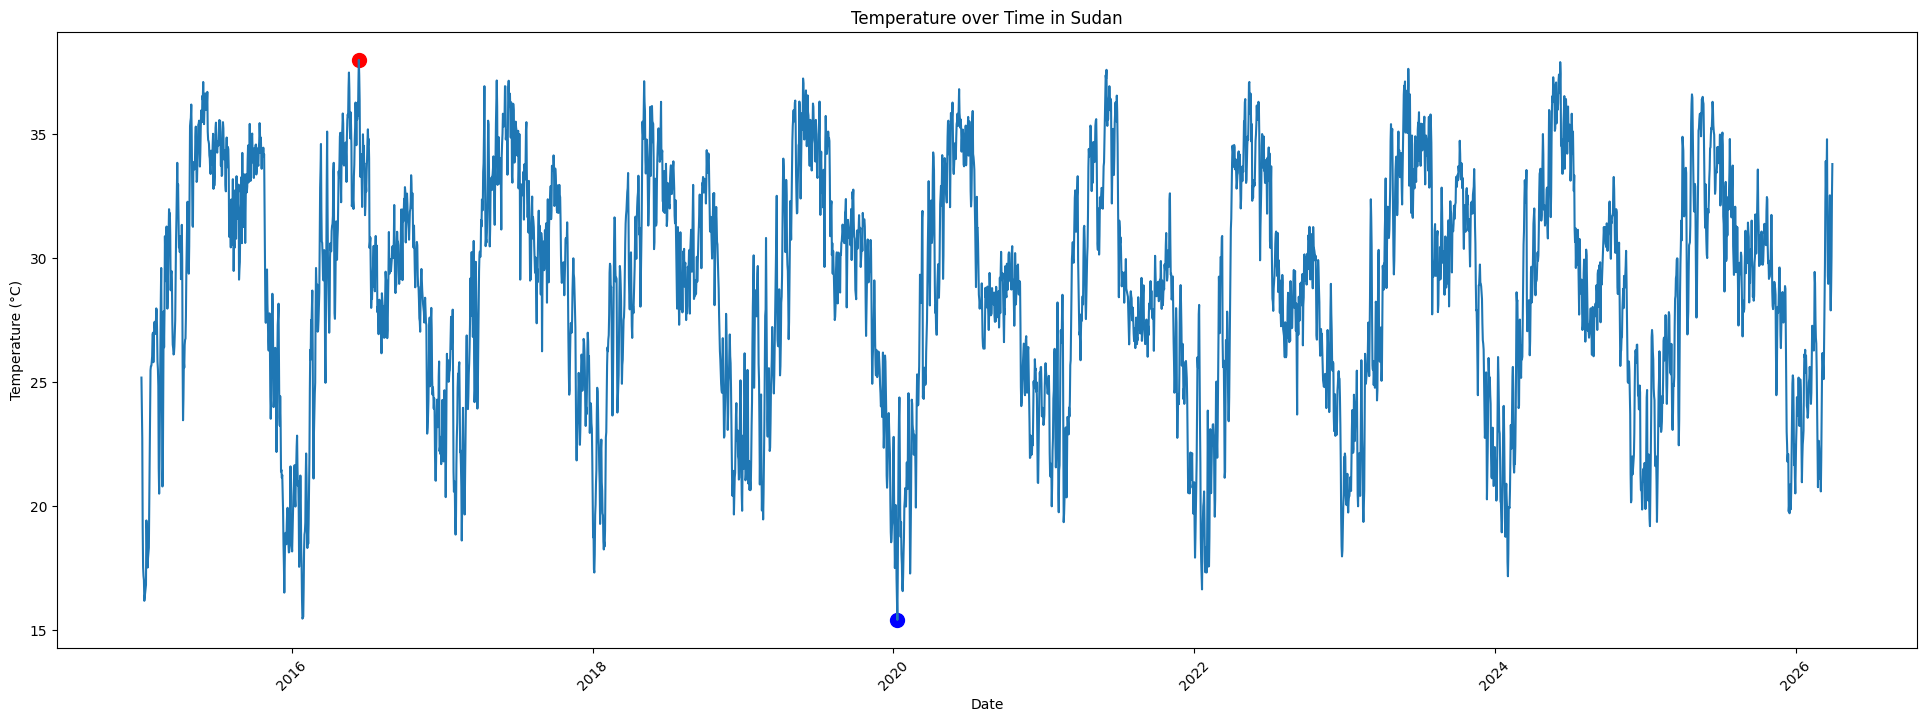

In [15]:
plt.figure(figsize=(24,8))

plt.plot('date', 'T2M', data=df_clean)

# Add Title and Labels
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.title('Temperature over Time in Sudan')

# Rotate the x-axis
plt.xticks(rotation=45)

# Annotate the highest and lowest temperature
highest_temp = df_clean['T2M'].idxmax()
lowest_temp = df_clean['T2M'].idxmin()

plt.scatter(df_clean['date'].loc[highest_temp], df_clean['T2M'].loc[highest_temp], color='red', marker='o', s=[100], label='Max Temp')

plt.scatter(df_clean['date'].loc[lowest_temp], df_clean['T2M'].loc[lowest_temp], color='blue', marker='o', s=[100], label='Max Temp')

plt.show()

### Correlation & Relationship Analysis

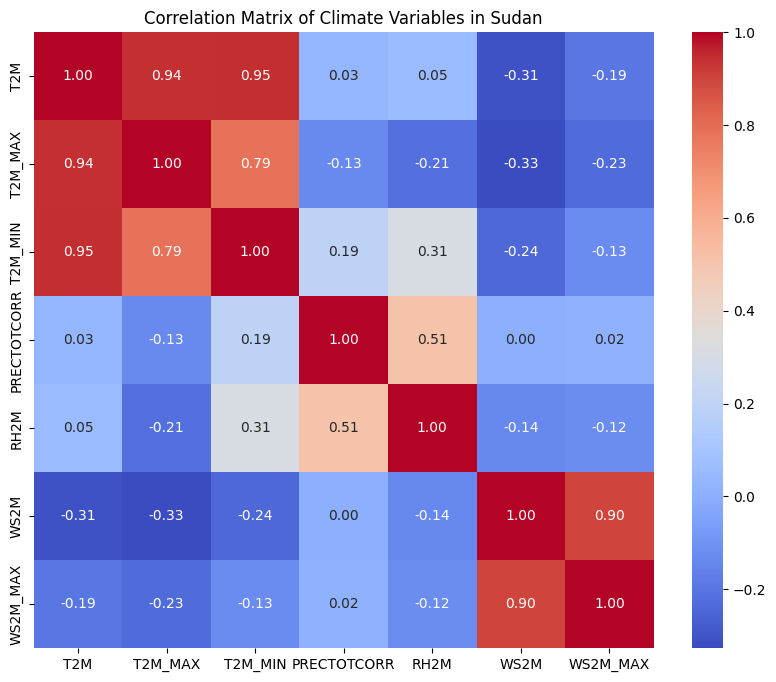

In [16]:
# Heatmap of correlations across all numeric columns
corr_matrix = df_clean[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Climate Variables in Sudan')
plt.show()

### Scatter Plots 

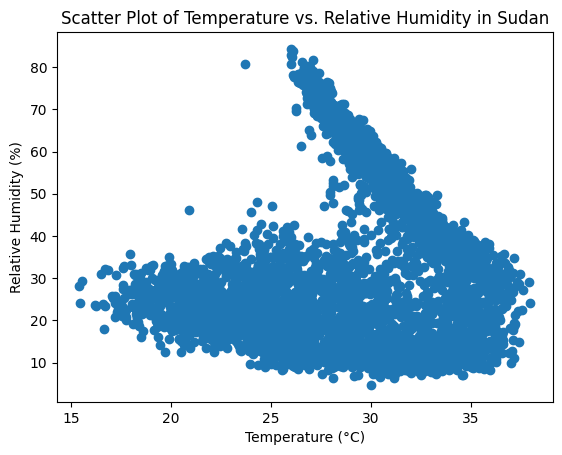

In [17]:
#scatter plot T2M vs RH2M

plt.scatter(df_clean['T2M'], df_clean['RH2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Sudan')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

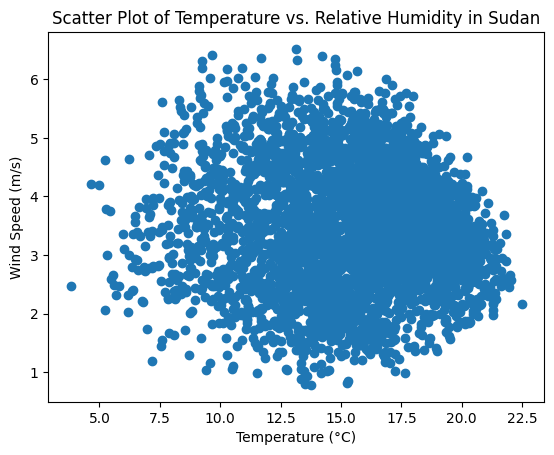

In [18]:
#scatter plot T2M_RANGE vs WS2M

plt.scatter(df_clean['T2M_RANGE'], df_clean['WS2M'])
plt.title('Scatter Plot of Temperature vs. Relative Humidity in Sudan')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.show()

### Distribution Analysis

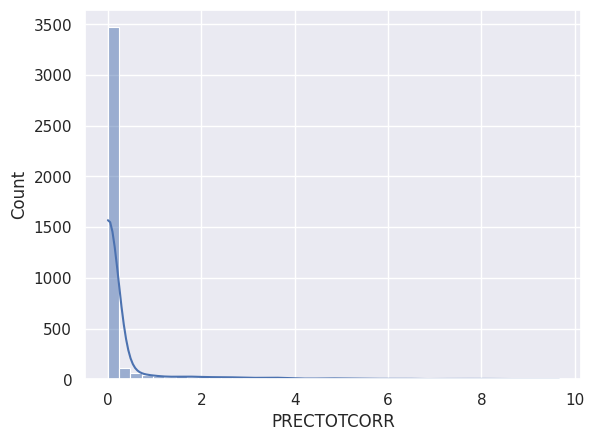

In [19]:
sns.set_theme(style="darkgrid")
sns.histplot(df_clean['PRECTOTCORR'], bins=40, kde=True)

plt.show()

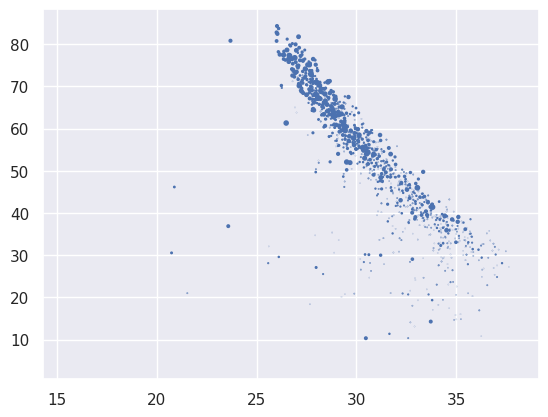

In [20]:
plt.scatter(x='T2M', y='RH2M', data=df_clean, s='PRECTOTCORR')